Работа с табличными данными

In [20]:
import pandas as pd

In [21]:
df = pd.read_csv('train.csv', sep="|")
df

,trustLevel,totalScanTimeInSeconds,grandTotal,lineItemVoids,scansWithoutRegistration,quantityModifications,scannedLineItemsPerSecond,valuePerSecond,lineItemVoidsPerPosition,fraud
0,5,1054,54.70,7,0,3,0.027514,0.051898,0.241379,0
1,3,108,27.36,5,2,4,0.129630,0.253333,0.357143,0
2,3,1516,62.16,3,10,5,0.008575,0.041003,0.230769,0
3,6,1791,92.31,8,4,4,0.016192,0.051541,0.275862,0
4,5,430,81.53,3,7,2,0.062791,0.189605,0.111111,0
...,...,...,...,...,...,...,...,...,...,...
1874,1,321,76.03,8,7,2,0.071651,0.236854,0.347826,0
1875,1,397,41.89,5,5,0,0.065491,0.105516,0.192308,1
1876,4,316,41.83,5,8,1,0.094937,0.132373,0.166667,0
1877,2,685,62.68,1,6,2,0.035036,0.091504,0.041667,0


In [22]:
df.dtypes

trustLevel                     int64
totalScanTimeInSeconds         int64
grandTotal                   float64
lineItemVoids                  int64
scansWithoutRegistration       int64
quantityModifications          int64
scannedLineItemsPerSecond    float64
valuePerSecond               float64
lineItemVoidsPerPosition     float64
fraud                          int64
dtype: object

In [23]:
df.isna().sum()

trustLevel                   0
totalScanTimeInSeconds       0
grandTotal                   0
lineItemVoids                0
scansWithoutRegistration     0
quantityModifications        0
scannedLineItemsPerSecond    0
valuePerSecond               0
lineItemVoidsPerPosition     0
fraud                        0
dtype: int64

In [24]:
df.fraud.value_counts()

fraud
0    1775
1     104
Name: count, dtype: int64

In [25]:
y = df["fraud"]
X = df.drop(columns=["fraud"])

In [26]:
df.describe()

,trustLevel,totalScanTimeInSeconds,grandTotal,lineItemVoids,scansWithoutRegistration,quantityModifications,scannedLineItemsPerSecond,valuePerSecond,lineItemVoidsPerPosition,fraud
count,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000
mean,3.401809,932.153273,50.864492,5.469931,4.904204,2.525279,0.058138,0.201746,0.745404,0.055349
std,1.709404,530.144640,28.940202,3.451169,3.139697,1.695472,0.278512,1.242135,1.327241,0.228720
min,1.000000,2.000000,0.010000,0.000000,0.000000,0.000000,0.000548,0.000007,0.000000,0.000000
25%,2.000000,474.500000,25.965000,2.000000,2.000000,1.000000,0.008384,0.027787,0.160000,0.000000
50%,3.000000,932.000000,51.210000,5.000000,5.000000,3.000000,0.016317,0.054498,0.350000,0.000000
75%,5.000000,1397.000000,77.285000,8.000000,8.000000,4.000000,0.032594,0.107313,0.666667,0.000000
max,6.000000,1831.000000,99.960000,11.000000,10.000000,5.000000,6.666667,37.870000,11.000000,1.000000


## Предобработка данных

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [28]:
X_train.shape

(1503, 9)

In [29]:
X_val.shape

(376, 9)

In [30]:
X_test = pd.read_csv("test.csv", sep="|")
X_test

,trustLevel,totalScanTimeInSeconds,grandTotal,lineItemVoids,scansWithoutRegistration,quantityModifications,scannedLineItemsPerSecond,valuePerSecond,lineItemVoidsPerPosition
0,4,467,88.48,4,8,4,0.014989,0.189465,0.571429
1,3,1004,58.99,7,6,1,0.026892,0.058755,0.259259
2,1,162,14.00,4,5,4,0.006173,0.086420,4.000000
3,5,532,84.79,9,3,4,0.026316,0.159380,0.642857
4,5,890,42.16,4,0,0,0.021348,0.047371,0.210526
...,...,...,...,...,...,...,...,...,...
498116,4,783,59.10,2,2,0,0.012771,0.075479,0.200000
498117,1,278,98.90,9,5,4,0.050360,0.355755,0.642857
498118,3,300,5.41,6,6,4,0.030000,0.018033,0.666667
498119,2,1524,33.97,2,5,3,0.005906,0.022290,0.222222


In [31]:
y_test = pd.read_csv("DMC-2019-realclass.csv", sep="|")["fraud"]
y_test.value_counts()

fraud
0    474394
1     23727
Name: count, dtype: int64

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [33]:
import torch

In [34]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

In [35]:
y_train = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
y_val = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

In [36]:
from torch.utils.data import TensorDataset, DataLoader

In [37]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=256)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=1024)

вес для редкого класса, чтобы модель его не пропускала

In [38]:
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()

In [39]:
pos_weight = n_neg / n_pos
pos_weight

tensor(17.1084)

## Модель

In [163]:
from dotenv import load_dotenv
import wandb
import os
import logging
import time

timestamp = str(time.time()).replace('.', '_')
log_file = f'part_2_{timestamp}.log'
logging.basicConfig(
    filename=log_file,
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    force=True
)

load_dotenv()

WANDB_API_KEY = os.getenv("WANDB_API_KEY")
WANDB_PROJECT = os.getenv("WANDB_PROJECT", "gp5")
WANDB_ENTITY = os.getenv("WANDB_ENTITY")

logging.info("Ключи для WANDB подгружены")


In [164]:
wandb.login(key=WANDB_API_KEY)
logging.info("Залогинились в wandb")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/evgeniy/.netrc


In [142]:
import torch.nn as nn

In [143]:
EPOCHS = 30
BATCH_SIZE = 64
LR = 0.001


config = {
    "model": "MLP",
    "optimizer": "Adam",
    "task": "fraud_detection",
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "pos_weight": pos_weight,
    "loss": "BCEWithLogitsLoss"
}

run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, name="nn_baseline", config=config)

model = nn.Sequential(
    nn.Linear(9, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
)

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,█▇▇▆▅▄▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
epoch,29
train/loss,0.24828


In [144]:
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [145]:
logging.info("Начали обучение модели")
for epoch in range(EPOCHS):
    epoch_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        epoch_loss += loss.item()
        optimizer.step()
    
    epoch_loss /= len(train_loader)

    logging.info(f"эпоха: {epoch}, loss:  {round(epoch_loss, 4)}")
    print("эпоха", epoch, "loss", round(epoch_loss, 4))
    wandb.log({"epoch": epoch, "train/loss": epoch_loss})

эпоха 0 loss 1.3086
эпоха 1 loss 1.2464
эпоха 2 loss 1.1668
эпоха 3 loss 1.036
эпоха 4 loss 0.909
эпоха 5 loss 0.7813
эпоха 6 loss 0.6729
эпоха 7 loss 0.5898
эпоха 8 loss 0.5254
эпоха 9 loss 0.4823
эпоха 10 loss 0.4448
эпоха 11 loss 0.4199
эпоха 12 loss 0.3992
эпоха 13 loss 0.3851
эпоха 14 loss 0.3674
эпоха 15 loss 0.3607
эпоха 16 loss 0.3496
эпоха 17 loss 0.34
эпоха 18 loss 0.327
эпоха 19 loss 0.3189
эпоха 20 loss 0.3085
эпоха 21 loss 0.3049
эпоха 22 loss 0.296
эпоха 23 loss 0.2868
эпоха 24 loss 0.2798
эпоха 25 loss 0.277
эпоха 26 loss 0.2688
эпоха 27 loss 0.2665
эпоха 28 loss 0.2594
эпоха 29 loss 0.2584


## Проверка

In [146]:
with torch.no_grad():
    logits = model(X_test)
    probs = torch.sigmoid(logits)

probs[:5]

tensor([[2.1638e-04],
        [1.0252e-01],
        [1.9648e-06],
        [5.8454e-05],
        [1.0376e-04]])

In [147]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_true = y_test.numpy()
y_prob = probs.numpy()

In [148]:
logging.info(f"На тесте ROC_AUC: {roc_auc_score(y_true, y_prob)}")
roc_auc_score(y_true, y_prob)



0.9740344397417077

In [ ]:
from sklearn.metrics import precision_score, recall_score

: 

In [149]:
y_pred = (y_prob > 0.5).astype(int)

In [150]:
logging.info(f"На тесте Precision: {precision_score(y_true, y_pred)}")
precision_score(y_true, y_pred)

0.35163701178898654

In [151]:
logging.info(f"На тесте Recall: {recall_score(y_true, y_pred)}")
recall_score(y_true, y_pred)

0.9478653011337295

## Попробуем подобрать порог

In [152]:
with torch.no_grad():
    val_prob = torch.sigmoid(model(X_val)).numpy()

val_true = y_val.numpy()

In [153]:
from sklearn.metrics import precision_recall_curve

target_recall = 0.90

prec, rec, thr = precision_recall_curve(val_true, val_prob)
best_threshold = thr[rec[:-1] >= target_recall].max()
logging.info(f"Подобрали порог {best_threshold}")
best_threshold

0.70900047

In [154]:
y_pred = (y_prob > best_threshold).astype(int)

In [155]:
logging.info(f"На тесте Precision: {precision_score(y_true, y_pred)}")
precision_score(y_true, y_pred)

0.42594740504860923

In [156]:
logging.info(f"На тесте Recall: {recall_score(y_true, y_pred)}")
recall_score(y_true, y_pred)

0.8512664896531378

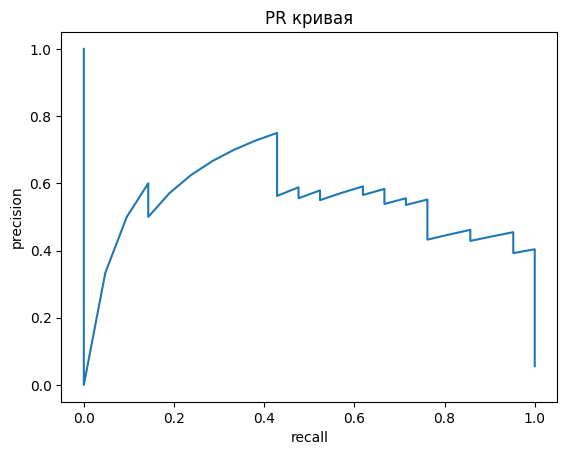

In [157]:
import matplotlib.pyplot as plt

plt.plot(rec, prec)
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("PR кривая")
plt.show()

In [158]:
import pickle

pickle.dump(model, open("models/model_fraud_1.pkl", 'wb'))

In [ ]:
artifact = wandb.Artifact(name="model_fraud_1", type="model", description="Тест логгирования модели Кати")

artifact.add_file("models/model_fraud_1.pkl")
artifact.add_file(log_file)
run.log_artifact(artifact)




<Artifact model_fraud_1>

In [160]:
run.finish()

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,██▇▆▅▄▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
epoch,29
train/loss,0.25838


In [161]:
wandb.finish() # потом переместить ниже

# ансамбль

In [57]:
import numpy as np

In [58]:
def build_model():
    return nn.Sequential(
        nn.Linear(9, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64, 32),
        nn.BatchNorm1d(32),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(32, 1),
        )

In [59]:
loss_fn2 = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [60]:
test_probs = []

for seed in range(5):
    torch.manual_seed(seed)
    net = build_model()
    opt = torch.optim.Adam(net.parameters(), lr=0.001, weight_decay=1e-4)

    net.train()
    for epoch in range(120):
        for xb, yb in train_loader:
            opt.zero_grad()
            loss = loss_fn2(net(xb), yb)
            loss.backward()
            opt.step()

    net.eval()
    with torch.no_grad():
        test_probs.append(torch.sigmoid(net(X_test)).numpy())

    print("сеть", seed, "обучена")

probs2 = np.mean(test_probs, axis=0)

сеть 0 обучена
сеть 1 обучена
сеть 2 обучена
сеть 3 обучена
сеть 4 обучена


In [ ]:
roc_auc_score(y_true, probs2)

0.9819678838542818

: 

: 

: 

: 

: 

: 

: 

In [ ]:
average_precision_score(y_true, probs2)

0.7559112712850714

: 

: 

: 

: 

: 

: 

: 